### 1 Setup

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Helper Functions

In [3]:
def detect_outliers(df: pd.DataFrame, col_name: str):
    """
    Function to detect possible outliers outside IQR in the
    feature `col_name` and return mask to detect outliers.
    """
    # Get 25th percentile.
    Q1 = df[col_name].quantile(0.25)

    # Get 75th percentile.
    Q3 = df[col_name].quantile(0.75)

    # Get IQR value.
    IQR = Q3 - Q1

    # Calculate lower and upper bound.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mask to identify outliers in given DataFrame.
    out_mask = (df[col_name] < lower_bound) | (df[col_name] > upper_bound)

    df_row_count, _ = df.shape
    out_row_count, _ = df[out_mask].shape
    out_per = round((out_row_count / df_row_count) * 100, 2)

    return out_mask, out_row_count, out_per

In [4]:
def pca(df: pd.DataFrame, class_label: str):
    """
    Function perform Principal Component Analysis.
    """
    X = df[df.columns.difference([class_label])]
    y = df[class_label]
    n, d = X.shape

    print(f"Reducing {d} dimensional data into 2 dimensions.")

    # Reducing features to 2 features using PCA.
    pca_model = PCA(n_components=2)
    pcs = pca_model.fit_transform(X)  # Principal Components.

    pc_df = pd.DataFrame(
        {
            "PC1": pcs[:, 0],
            "PC2": pcs[:, 1],
            class_label: y,
        }
    )
    pc_df[class_label] = pc_df[class_label].astype("category")

    return pc_df

#### Import dataset

In [5]:
# https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
# !gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2

od_df = pd.read_csv("data/online_delivery_warehouses.csv")

display(od_df.sample(5, random_state=rng))

row_count, col_count = od_df.shape
print(f"Dataset has {row_count:,} rows and {col_count} columns.")

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
338,2,3,333,7021,15601,15,550,3
192,3,5509,1461,2251,547,187,409,3
286,3,7149,2247,1242,1619,1226,128,3
38,3,4591,15729,16709,33,6956,433,2
190,3,16936,6250,1981,7332,118,64,1


Dataset has 440 rows and 8 columns.


#### Objective

1. Perform EDA
2. Train test split
3. Feature Scaling
4. Training base model
5. Model Evaluation

### 2 EDA

#### Metadata

In [6]:
od_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Region            440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   class             440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [7]:
od_df["Region"] = od_df["Region"].astype("category")
od_df["class"] = od_df["class"].astype("category")
od_df.select_dtypes(include="number").columns.tolist()

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

#### Correlation Analysis

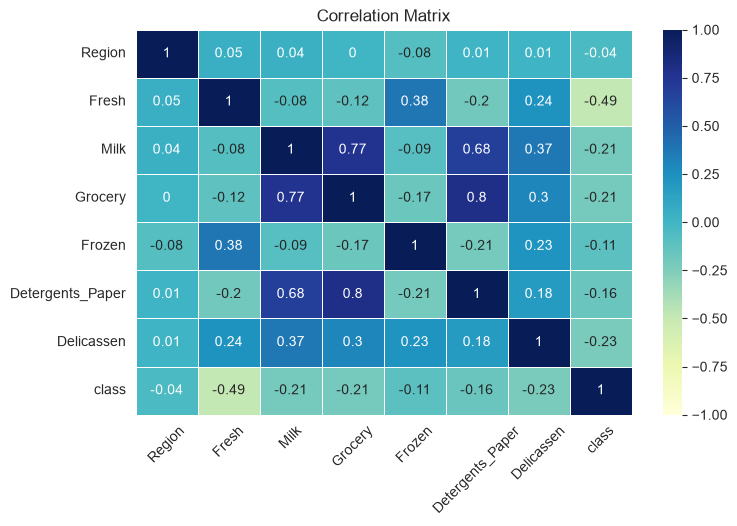

In [8]:
corr = od_df.corr(method="spearman").round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)

plt.show()

#### Target `class`

In [9]:
od_df["class"].value_counts(normalize=True).sort_values().mul(100).round(2).reset_index()

,class,proportion
0,1,19.77
1,3,39.32
2,2,40.91


### 3 Outlier Treatment

#### Detect Outliers

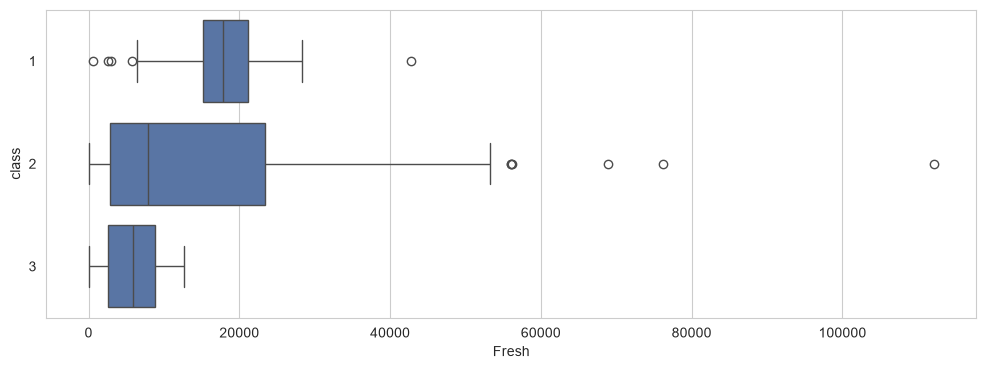

In [10]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Fresh", y="class", orient="h")
plt.show()

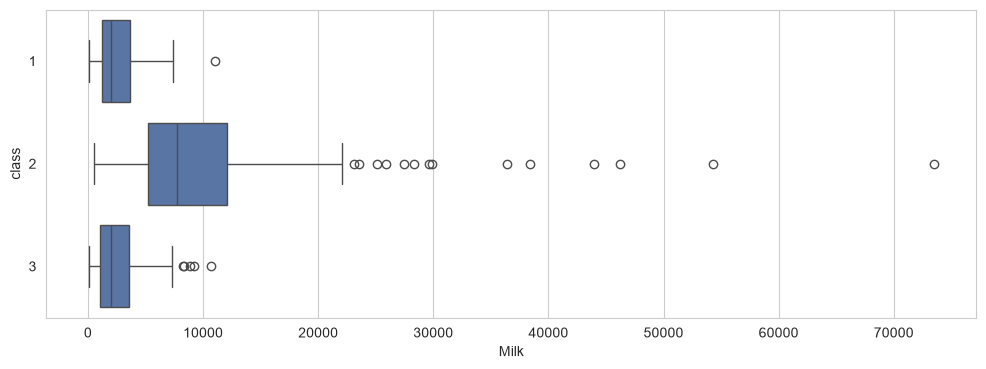

In [11]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Milk", y="class", orient="h")
plt.show()

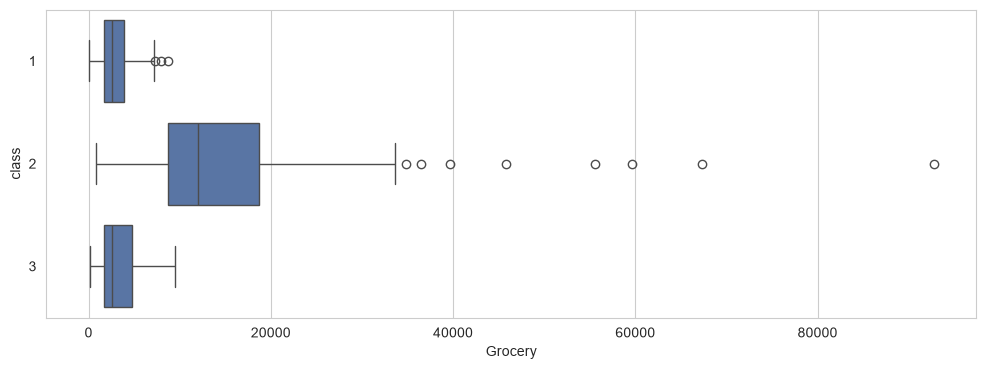

In [12]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Grocery", y="class", orient="h")
plt.show()

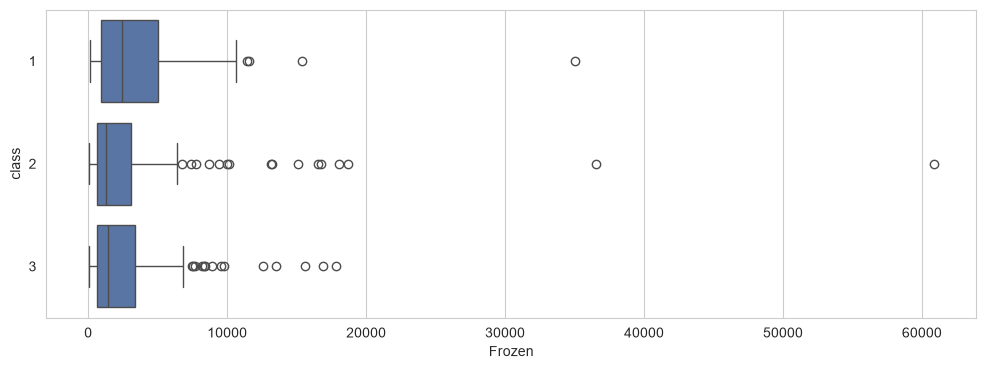

In [13]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Frozen", y="class", orient="h")
plt.show()

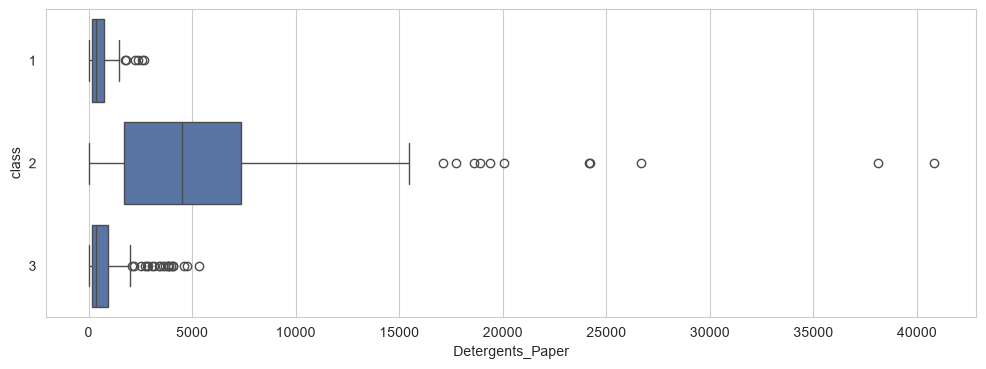

In [14]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Detergents_Paper", y="class", orient="h")
plt.show()

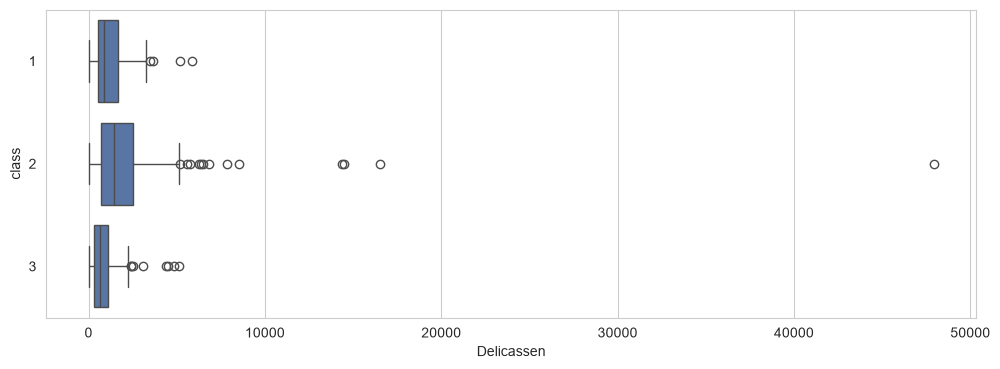

In [15]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=od_df, x="Delicassen", y="class", orient="h")
plt.show()

In [16]:
print("Number of rows outside of IQR for each feature:\n")

for _, f_name in enumerate(od_df.select_dtypes(include="number").columns):
    _, out_row_count, out_per = detect_outliers(od_df, f_name)
    print(f"Feature `{f_name}`: {out_row_count} rows ({out_per}% of data)")

Number of rows outside of IQR for each feature:

Feature `Fresh`: 20 rows (4.55% of data)
Feature `Milk`: 28 rows (6.36% of data)
Feature `Grocery`: 24 rows (5.45% of data)
Feature `Frozen`: 43 rows (9.77% of data)
Feature `Detergents_Paper`: 30 rows (6.82% of data)
Feature `Delicassen`: 27 rows (6.14% of data)


#### Delete Outliers

In [17]:
od_wo_df = od_df.copy()  # Without outliers.
tot_out_mask = pd.Series(False, index=od_df.index)

print("Deleting rows outside of IQR.")
for _, f_name in enumerate(od_wo_df.select_dtypes(include="number").columns):
    out_mask, _, _ = detect_outliers(od_wo_df, f_name)
    tot_out_mask |= out_mask

od_wo_df = od_wo_df[~tot_out_mask]

rc_bfr, _ = od_df.shape
rc_aft, _ = od_wo_df.shape
lc = rc_bfr - rc_aft
lp = lc / rc_bfr * 100
print(f"{lc} out of {rc_bfr} rows i.e., ~{lp:.0f}% of data are outliers.")

Deleting rows outside of IQR.
108 out of 440 rows i.e., ~25% of data are outliers.


- Significant amount, roughly 25%, of data is outside the range of IQR.
- Instead of deleting outliers lets use Robust Scaling to minimize the impact of outliers.

#### Features

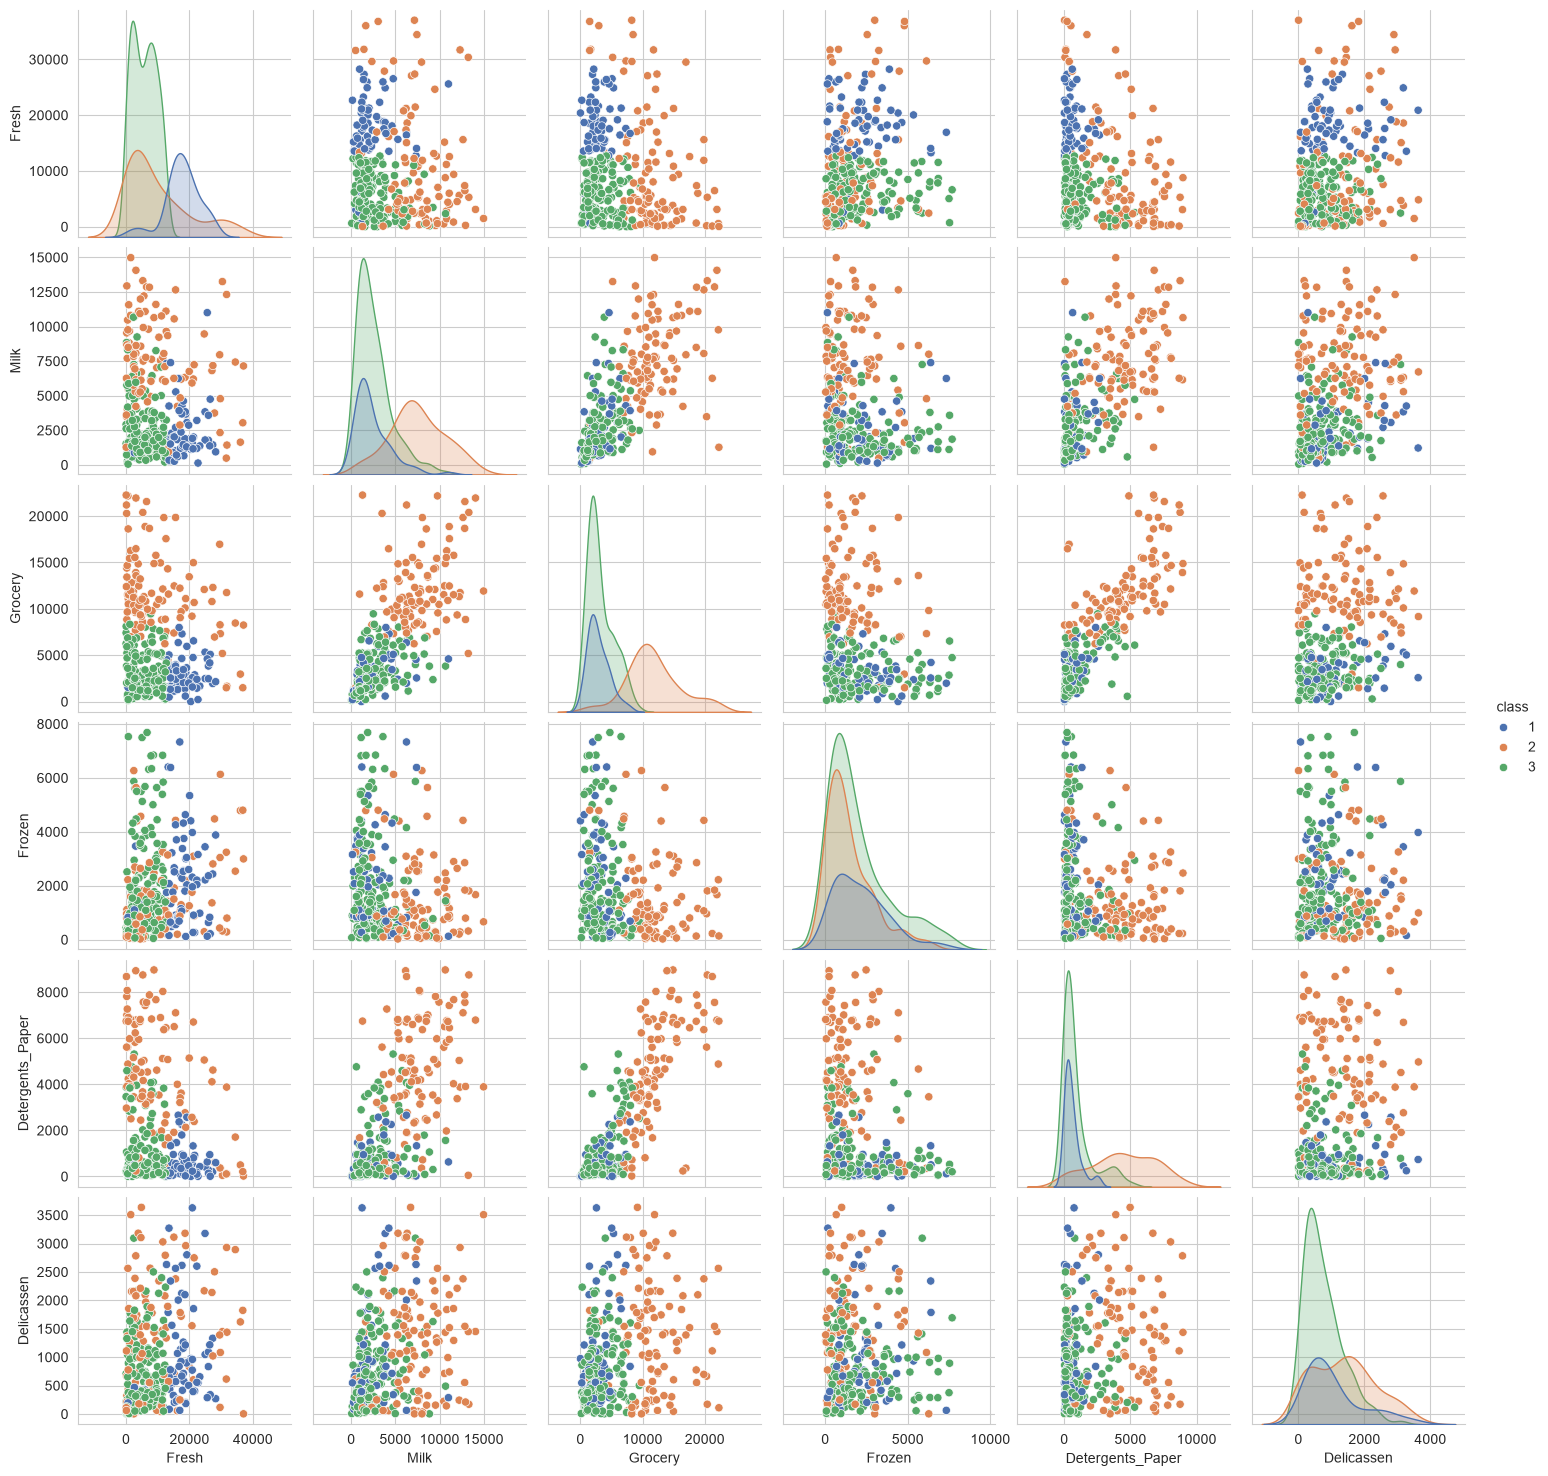

In [18]:
sns.pairplot(data=od_wo_df, hue="class")
plt.show()

### 4 PCA

#### PCA on full Dataset

In [19]:
pc_df1 = pca(od_df, "class")

Reducing 7 dimensional data into 2 dimensions.


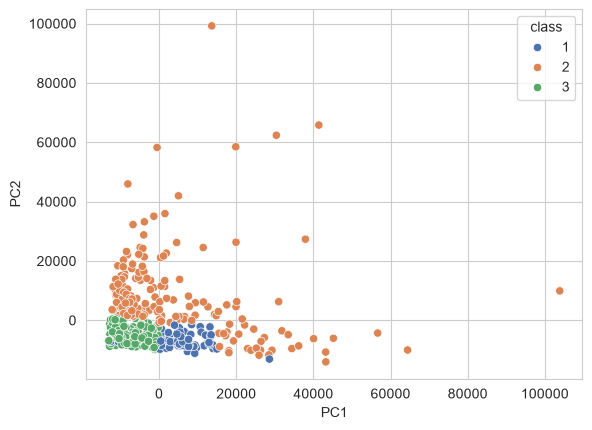

In [20]:
sns.scatterplot(data=pc_df1, x="PC1", y="PC2", hue="class")
plt.yticks(rotation=0)
plt.show()

#### PCA on Dataset without outliers

In [21]:
pc_df2 = pca(od_wo_df, "class")

Reducing 7 dimensional data into 2 dimensions.


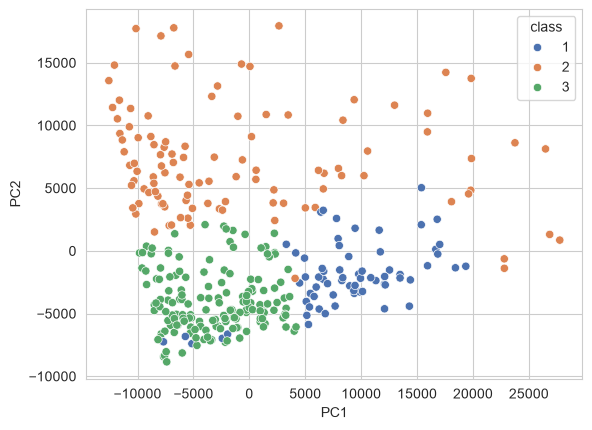

In [22]:
sns.scatterplot(data=pc_df2, x="PC1", y="PC2", hue="class")
plt.yticks(rotation=0)
plt.show()

### 5 Training Setup

#### Train test split

In [23]:
od_df.columns

Index(['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen', 'class'], dtype='str')

In [24]:
X = od_df[od_df.columns.difference(["class"])]
y = od_df["class"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((308, 7), (132, 7), (308,), (132,))

In [26]:
pd.DataFrame(
    {
        "Count": (counts := y_train.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
class,,
2,126,40.91
3,121,39.29
1,61,19.81


In [27]:
pd.DataFrame(
    {
        "Count": (counts := y_test.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
class,,
2,54,40.91
3,52,39.39
1,26,19.70


#### Define Feature Encoding and Scaling

In [28]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 308 entries, 289 to 209
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Delicassen        308 non-null    int64   
 1   Detergents_Paper  308 non-null    int64   
 2   Fresh             308 non-null    int64   
 3   Frozen            308 non-null    int64   
 4   Grocery           308 non-null    int64   
 5   Milk              308 non-null    int64   
 6   Region            308 non-null    category
dtypes: category(1), int64(6)
memory usage: 17.2 KB


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("feature_encoding", OneHotEncoder(), ["Region"]),
        ("feature_scaling", RobustScaler(), X_train.columns.difference(["Region"])),
    ]
)

### 6 Training

#### Base Model

In [30]:
base_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("model", KNeighborsClassifier()),
    ]
)

base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Delicassen','Detergents_Paper','Fresh',...,'Grocery','Milk','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('feature_encoding', ...), ('feature_scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

#### Training Accuracy

In [31]:
tr_acc = base_pipeline.score(X_train, y_train)
print("Training accuracy:", round(tr_acc * 100, 2))

Training accuracy: 92.86


#### Testing Accuracy

In [32]:
ts_acc = base_pipeline.score(X_test, y_test)
print("Testing accuracy:", round(ts_acc * 100, 2))

Testing accuracy: 87.12


### 7 Hyperparameter Tuning

#### Hyperparameter K

In [33]:
k_vals = list(range(3, 27, 2))
k_vals

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]

#### K-Fold Cross Validation

In [34]:
cv_acc = list()
for k in k_vals:
    cv_pipeline = Pipeline(
        steps=[
            ("preprocessing", clone(preprocessor)),
            ("feature_selection", SelectKBest(f_classif, k=5)),
            ("model", KNeighborsClassifier(n_neighbors=k, weights="distance", metric="minkowski", p=1)),
        ]
    )
    acc_scores = cross_val_score(cv_pipeline, X_train, y_train, cv=5, scoring="balanced_accuracy")
    cv_acc.append(acc_scores.mean())

#### Plot K vs Accuracy

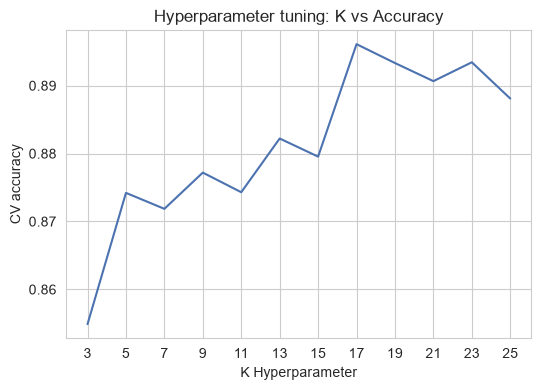

In [35]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=k_vals, y=cv_acc)
plt.title("Hyperparameter tuning: K vs Accuracy")
plt.xlabel("K Hyperparameter")
plt.ylabel("CV accuracy")
plt.xticks(k_vals)

plt.show()

In [36]:
best_k = 17

### 8 Model Evaluation

#### Final Pipeline

In [37]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("feature_selection", SelectKBest(f_classif, k=5)),
        ("model", KNeighborsClassifier(n_neighbors=best_k, weights="distance", metric="minkowski", p=1)),
    ]
)

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Delicassen','Detergents_Paper','Fresh',...,'Grocery','Milk','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('feature_encoding', ...), ('feature_scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

#### Final Testing Accuracy

In [38]:
y_test_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.87      0.77      0.82        26
           2       0.96      0.93      0.94        54
           3       0.91      1.00      0.95        52

    accuracy                           0.92       132
   macro avg       0.91      0.90      0.90       132
weighted avg       0.92      0.92      0.92       132



In [39]:
final_test_acc = final_pipeline.score(X_test, y_test)  # Highest accuracy seen: 92.42
round(final_test_acc * 100, 2)

92.42

Finally we are able to get the Testing accuracy of 92.42% which is close to Training accuracy 92.86%.